In [1]:
# ==========================================
#  IMPORT LIBRARIES & SETUP
# ==========================================
%load_ext autoreload
%autoreload 2

from metrics import evaluate
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import os

## DATA LOADING

In [2]:
articles=pd.read_parquet('data/articles_processed.parquet')
customers=pd.read_parquet('data/customers_processed.parquet')
transactions=pd.read_parquet('data/transactions_processed.parquet')


In [3]:
#================================================================================
#                  TRAIN-VALIDATION-TEST SPLIT
#================================================================================
last_date = transactions['t_dat'].max()
test_start = last_date - pd.Timedelta(days=6)    # last week
val_start = test_start - pd.Timedelta(days=7)    # the week before last

train = transactions[transactions['t_dat'] < val_start]
val = transactions[(transactions['t_dat'] >= val_start) & (transactions['t_dat'] < test_start)]
test = transactions[transactions['t_dat'] >= test_start]

# val and test must each cover exactly 7 distinct days
print(val['t_dat'].nunique(), test['t_dat'].nunique())

# no overlap: each part ends strictly before the next one starts
print(train['t_dat'].max() < val_start, val['t_dat'].max() < test_start)

# nothing lost or duplicated
print((len(train) + len(val) + len(test)) == len(transactions))

7 7
True True
True


In [4]:
# Մոդելի աշխատանքը գնահատելու համար

total_catalog_items = articles['article_id'].nunique()
sales_series = train['article_id'].value_counts()

total_sales = len(train)

novelty_dict = (
    (-np.log2(sales_series / total_sales)).to_dict()
)


## BASELINE 1: Global Popularity

In [5]:
top12_popular = train['article_id'].value_counts().head(12).index.tolist()
actuals = val.groupby('customer_id')['article_id'].unique().to_dict()

predictions = {user: top12_popular for user in actuals.keys()}

pop_results = evaluate(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== GLOBAL POPULARITY BASELINE RESULTS ===")
for metric, value in pop_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== GLOBAL POPULARITY BASELINE RESULTS ===
Precision@12   : 0.002341
Recall@12      : 0.008971
MAP@12         : 0.003444
NDCG@12        : 0.006318
Novelty@12     : 10.216682
Coverage       : 0.000114


## BASELINE 2: Recent Popularity

In [6]:
end = train['t_dat'].max()
start = end - pd.Timedelta(days=6)

top12_recent = (
    train[train['t_dat'] >= start]
    .groupby('article_id')
    .size()
    .nlargest(12)
    .index.tolist()
)

actuals = val.groupby('customer_id')['article_id'].unique().to_dict()
actuals = {user: set(items) for user, items in actuals.items()}


predictions = {user: top12_recent for user in actuals.keys()}

recent_pop_results = evaluate(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== RECENT (LAST 7 DAYS) POPULARITY BASELINE RESULTS ===")
for metric, value in recent_pop_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== RECENT (LAST 7 DAYS) POPULARITY BASELINE RESULTS ===
Precision@12   : 0.004933
Recall@12      : 0.020905
MAP@12         : 0.006604
NDCG@12        : 0.012605
Novelty@12     : 13.269735
Coverage       : 0.000114


## BASELINE 3: Repeat Purchases + Recent Popularity fallback

In [7]:

customer_article_counts = (
    train.groupby(['customer_id', 'article_id'])
    .size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'count'], ascending=[True, False])
)

customer_history = customer_article_counts.groupby('customer_id')['article_id'].apply(list).to_dict()

def predict_user(c_id):
    own = customer_history.get(c_id, [])
    if len(own) < 12:
        fill = [p for p in top12_recent if p not in own]
        own = own + fill[:12 - len(own)]
    return own[:12]

actuals = val.groupby('customer_id')['article_id'].unique().to_dict()
actuals = {user: set(items) for user, items in actuals.items()}

predictions = {c: predict_user(c) for c in actuals.keys()}

repeat_pop_results = evaluate(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== REPEAT PURCHASES + RECENT POPULARITY BASELINE RESULTS ===")
for metric, value in repeat_pop_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== REPEAT PURCHASES + RECENT POPULARITY BASELINE RESULTS ===
Precision@12   : 0.004374
Recall@12      : 0.023520
MAP@12         : 0.009352
NDCG@12        : 0.015019
Novelty@12     : 14.318081
Coverage       : 0.569129



## BASELINE 4: Limited History + Recent Popularity

In [8]:

K_HISTORY = 5  

def predict_baseline4(customer_id):
    own = customer_history.get(customer_id, [])[:K_HISTORY]
    
    if len(own) < 12:
        fill = [p for p in top12_recent if p not in own]
        own = own + fill[:12 - len(own)]
        
    return own[:12]

actuals = val.groupby('customer_id')['article_id'].unique().to_dict()
actuals = {user: set(items) for user, items in actuals.items()}

predictions = {c: predict_baseline4(c) for c in actuals.keys()}

b4_results = evaluate(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== BASELINE 4 (TOP 5 REPEAT + RECENT POPULARITY) RESULTS ===")
for metric, value in b4_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== BASELINE 4 (TOP 5 REPEAT + RECENT POPULARITY) RESULTS ===
Precision@12   : 0.005515
Recall@12      : 0.026711
MAP@12         : 0.009696
NDCG@12        : 0.016547
Novelty@12     : 13.521146
Coverage       : 0.427062


In [9]:

all_baselines = {
    'Global Popularity': pop_results,
    'Recent Popularity (7d)': recent_pop_results,
    'Repeat + Popularity Fallback': repeat_pop_results,
    'Top 5 Repeat + Popularity': b4_results
}

df_results = pd.DataFrame(all_baselines).T

pd.set_option('display.float_format', lambda x: '%.5f' % x)

print(df_results)

                              Precision@12  Recall@12  MAP@12  NDCG@12  \
Global Popularity                  0.00234    0.00897 0.00344  0.00632   
Recent Popularity (7d)             0.00493    0.02091 0.00660  0.01260   
Repeat + Popularity Fallback       0.00437    0.02352 0.00935  0.01502   
Top 5 Repeat + Popularity          0.00551    0.02671 0.00970  0.01655   

                              Novelty@12  Coverage  
Global Popularity               10.21668   0.00011  
Recent Popularity (7d)          13.26973   0.00011  
Repeat + Popularity Fallback    14.31808   0.56913  
Top 5 Repeat + Popularity       13.52115   0.42706  


In [10]:
df_results

,Precision@12,Recall@12,MAP@12,NDCG@12,Novelty@12,Coverage
Global Popularity,0.00234,0.00897,0.00344,0.00632,10.21668,0.00011
Recent Popularity (7d),0.00493,0.02091,0.00660,0.01260,13.26973,0.00011
Repeat + Popularity Fallback,0.00437,0.02352,0.00935,0.01502,14.31808,0.56913
Top 5 Repeat + Popularity,0.00551,0.02671,0.00970,0.01655,13.52115,0.42706


<Figure size 1000x500 with 0 Axes>

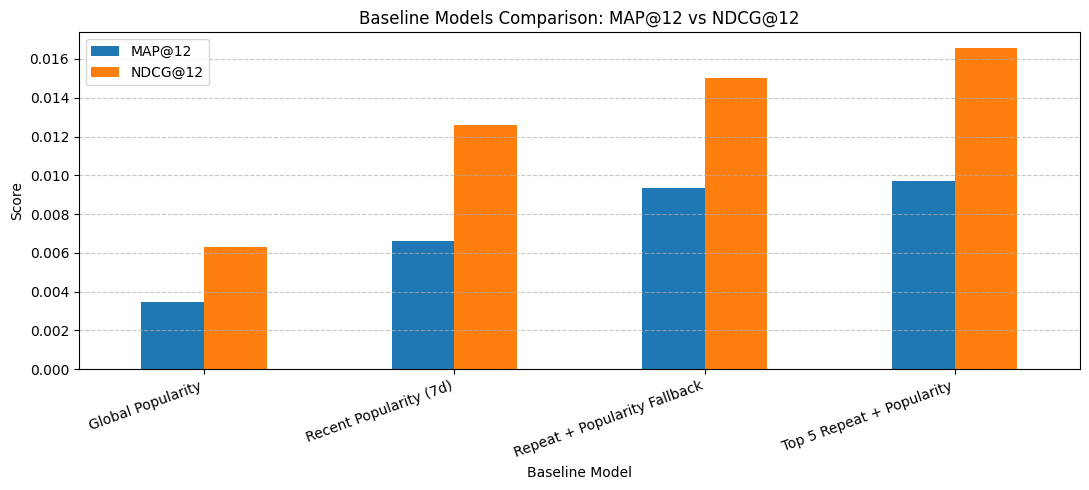

In [11]:

plt.figure(figsize=(10, 5))
df_results[['MAP@12', 'NDCG@12']].plot(kind='bar', figsize=(11, 5))
plt.title('Baseline Models Comparison: MAP@12 vs NDCG@12')
plt.ylabel('Score')
plt.xlabel('Baseline Model')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
os.makedirs('results', exist_ok=True)
df_results.to_csv('results/val_results.csv')